   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


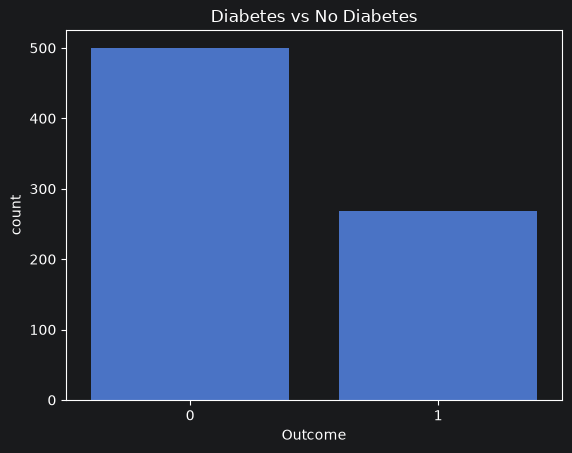

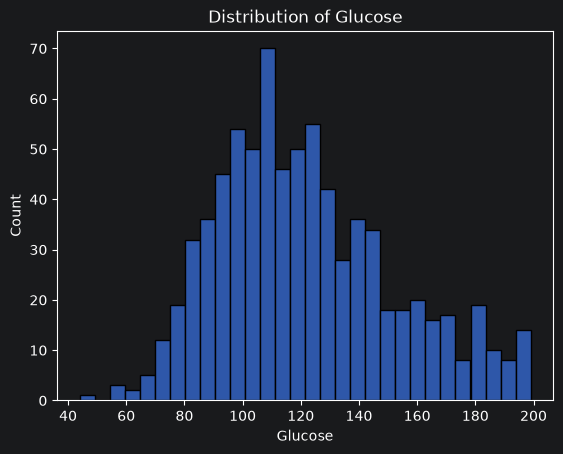

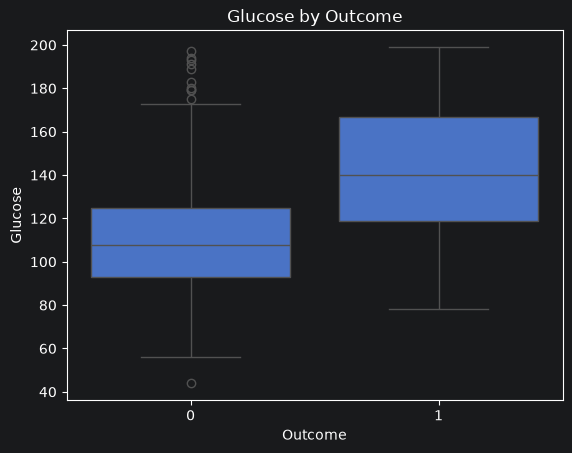

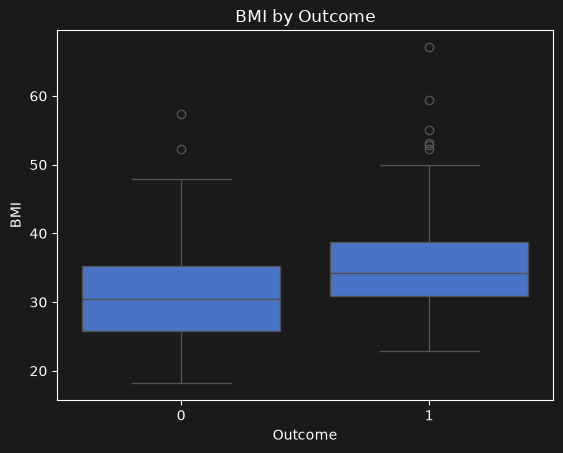

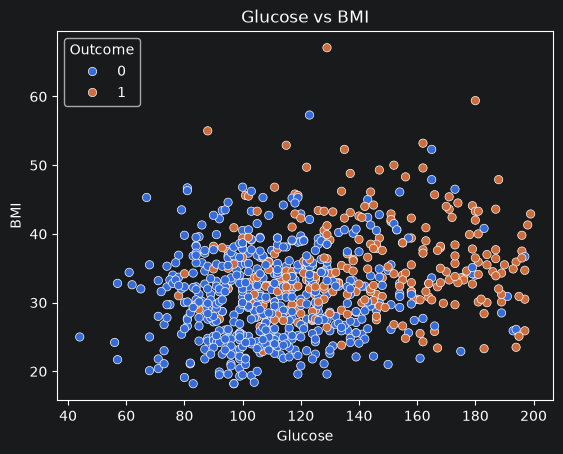

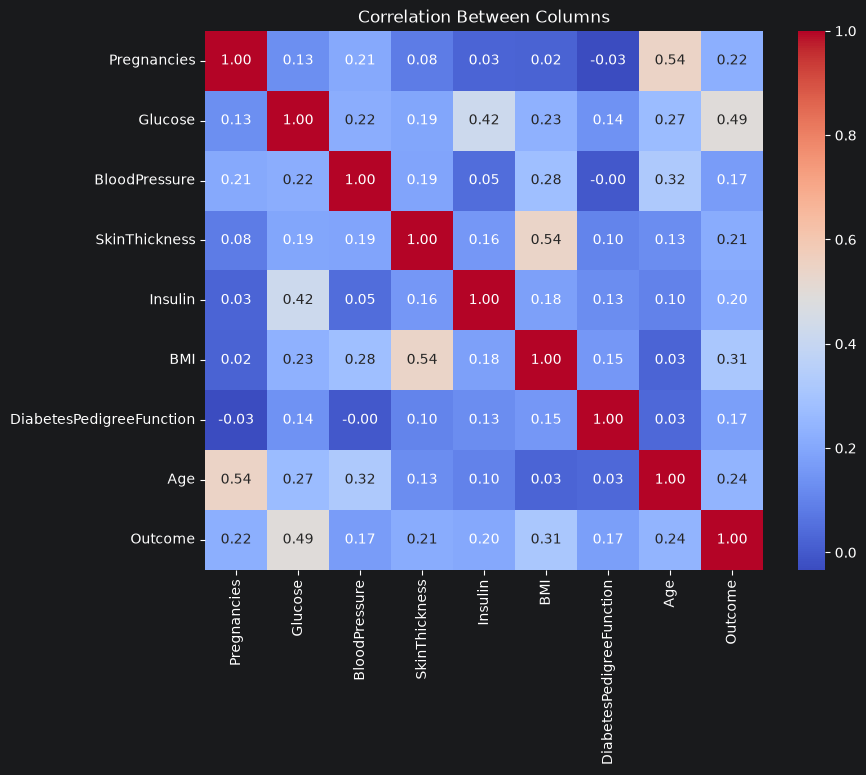

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- 1. Load the data ----------
df = pd.read_csv("diabetes.csv")
print(df.head())

# ---------- 2. Fix the fake zeros ----------
# In these columns, a 0 means "not measured". Replace it with the median value.
cols_with_fake_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in cols_with_fake_zeros:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

# ---------- Chart 1: How many people have diabetes? ----------
# 0 = no diabetes, 1 = diabetes
sns.countplot(data=df, x="Outcome")
plt.title("Diabetes vs No Diabetes")
plt.show()

# ---------- Chart 2: Glucose levels ----------
sns.histplot(data=df, x="Glucose", bins=30)
plt.title("Distribution of Glucose")
plt.show()

# ---------- Chart 3: Glucose for each group ----------
sns.boxplot(data=df, x="Outcome", y="Glucose")
plt.title("Glucose by Outcome")
plt.show()

# ---------- Chart 4: BMI for each group ----------
sns.boxplot(data=df, x="Outcome", y="BMI")
plt.title("BMI by Outcome")
plt.show()

# ---------- Chart 5: Glucose vs BMI ----------
sns.scatterplot(data=df, x="Glucose", y="BMI", hue="Outcome")
plt.title("Glucose vs BMI")
plt.show()

# ---------- Chart 6: Which columns are related? ----------
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Between Columns")
plt.show()


STEP 1: Loading data
  Training rows: 669
  Test rows    : 168
  Input columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

STEP 2: Creating models
  Models: ['Logistic Regression', 'Decision Tree', 'Random Forest']

STEP 3: Training and scoring
              Model  Accuracy  Precision  Recall    F1
Logistic Regression     0.470      0.274   0.451 0.341
      Decision Tree     0.524      0.277   0.353 0.310
      Random Forest     0.607      0.174   0.078 0.108

STEP 4: Drawing the model comparison chart


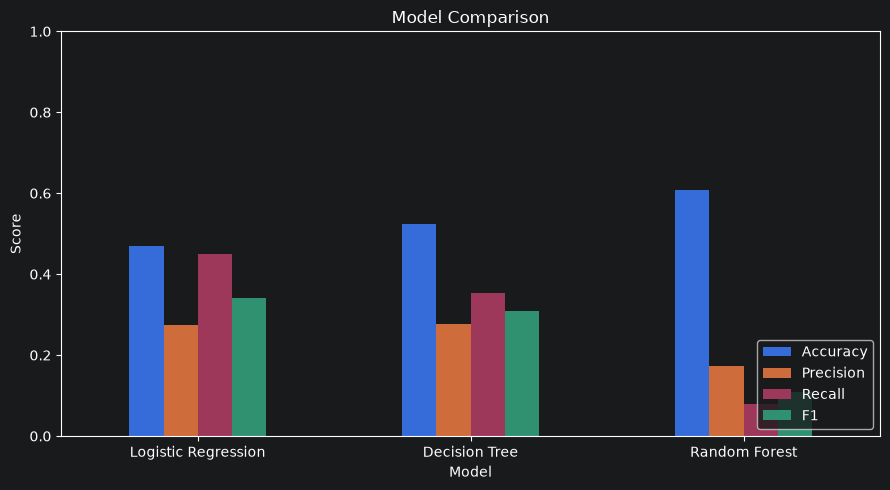


STEP 5: Selecting the best model
  Best model (highest recall): Logistic Regression

STEP 6: Detailed results for Logistic Regression
              precision    recall  f1-score   support

 No Diabetes       0.67      0.48      0.56       117
    Diabetes       0.27      0.45      0.34        51

    accuracy                           0.47       168
   macro avg       0.47      0.46      0.45       168
weighted avg       0.55      0.47      0.49       168



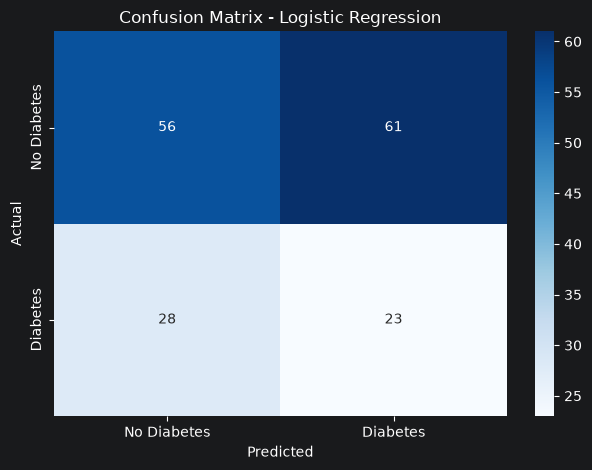


STEP 7: Saving the best model
  Saved: best_model.pkl
  Saved in the results folder: model_comparison.csv, model_comparison.png,
         classification_report.txt, confusion_matrix.png

DONE


In [2]:
"""
train_models.py  -  Step 4 of the Diabetes Prediction project: MODEL TRAINING

What this script does:
    1. Loads the training and test data saved by preprocessing.py
    2. Trains three classification models
    3. Compares them using Accuracy, Precision, Recall and F1
    4. Selects the best model (highest Recall)
    5. Draws confusion matrices and a comparison chart
    6. Saves the best model and all results

Input files : X_train.csv, X_test.csv, y_train.csv, y_test.csv
Output files: best_model.pkl, results/ folder (tables, charts, report)
"""

import os
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# A folder to keep every result together (useful for the report)
os.makedirs("results", exist_ok=True)


# =====================================================================
# STEP 1: LOAD THE PREPROCESSED DATA
# =====================================================================
# X = the input columns (Glucose, BMI, Age, ...), already cleaned and scaled.
# y = the answer column (0 = no diabetes, 1 = diabetes).
# "train" is used to teach the model, "test" is kept hidden to check it.
print("STEP 1: Loading data")

X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()   # .squeeze() turns the table into a simple list
y_test = pd.read_csv("y_test.csv").squeeze()

print("  Training rows:", len(X_train))
print("  Test rows    :", len(X_test))
print("  Input columns:", list(X_train.columns))


# =====================================================================
# STEP 2: CREATE THE MODELS
# =====================================================================
# Three different algorithms, so we can compare them:
#   - Logistic Regression: simple and fast, a good baseline
#   - Decision Tree      : a flowchart of yes/no questions
#   - Random Forest      : many decision trees voting together
# class_weight="balanced" makes the models pay more attention to the
# smaller group (people with diabetes), because the two groups are uneven.
print("\nSTEP 2: Creating models")

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"),
}
print("  Models:", list(models.keys()))


# =====================================================================
# STEP 3: TRAIN EACH MODEL AND SCORE IT
# =====================================================================
# fit()     -> the model learns from the training data
# predict() -> the model answers the test rows it has never seen
# Then we compare its answers with the true answers (y_test).
#
#   Accuracy  : share of all predictions that were correct
#   Precision : when the model says "diabetes", how often it is right
#   Recall    : of all real diabetes cases, how many the model found
#   F1        : one number that balances precision and recall
print("\nSTEP 3: Training and scoring")

results = []
all_predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    all_predictions[name] = predictions
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions),
    })

results_table = pd.DataFrame(results).round(3)
print(results_table.to_string(index=False))

results_table.to_csv("results/model_comparison.csv", index=False)


# =====================================================================
# STEP 4: COMPARISON CHART
# =====================================================================
# A bar chart of all metrics makes the comparison easy to see.
print("\nSTEP 4: Drawing the model comparison chart")

results_table.set_index("Model")[["Accuracy", "Precision", "Recall", "F1"]].plot(
    kind="bar", figsize=(9, 5), rot=0)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("results/model_comparison.png", dpi=150)
plt.show()


# =====================================================================
# STEP 5: PICK THE BEST MODEL
# =====================================================================
# In disease detection, missing a real case is the worst mistake,
# so we choose the model with the highest RECALL.
print("\nSTEP 5: Selecting the best model")

best_name = results_table.sort_values("Recall", ascending=False).iloc[0]["Model"]
best_model = models[best_name]
best_predictions = all_predictions[best_name]
print("  Best model (highest recall):", best_name)


# =====================================================================
# STEP 6: LOOK AT THE BEST MODEL'S MISTAKES
# =====================================================================
# The classification report gives precision, recall and F1 for each class.
# The confusion matrix shows the four possible outcomes:
#   top-left     = correctly said "no diabetes"
#   top-right    = false alarm (said diabetes, but the person is healthy)
#   bottom-left  = MISSED CASE (said healthy, but the person has diabetes)
#   bottom-right = correctly said "diabetes"
print("\nSTEP 6: Detailed results for", best_name)

report = classification_report(y_test, best_predictions,
                               target_names=["No Diabetes", "Diabetes"])
print(report)

with open("results/classification_report.txt", "w") as file:
    file.write("Best model: " + best_name + "\n\n" + report)

sns.heatmap(confusion_matrix(y_test, best_predictions), annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes", "Diabetes"], yticklabels=["No Diabetes", "Diabetes"])
plt.title("Confusion Matrix - " + best_name)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("results/confusion_matrix.png", dpi=150)
plt.show()


# =====================================================================
# STEP 7: SAVE THE BEST MODEL
# =====================================================================
# joblib saves the trained model to a file, so the app can load it later
# without training again.
print("\nSTEP 7: Saving the best model")

joblib.dump(best_model, "best_model.pkl")
print("  Saved: best_model.pkl")
print("  Saved in the results folder: model_comparison.csv, model_comparison.png,")
print("         classification_report.txt, confusion_matrix.png")
print("\nDONE")

STEP 1: Loading model, scaler and data
  Model type: LogisticRegression
  Test rows : 168

TEST 1: Score on the hidden test data
  Accuracy : 0.47
  Precision: 0.274
  Recall   : 0.451
  F1 score : 0.341
              precision    recall  f1-score   support

 No Diabetes       0.67      0.48      0.56       117
    Diabetes       0.27      0.45      0.34        51

    accuracy                           0.47       168
   macro avg       0.47      0.46      0.45       168
weighted avg       0.55      0.47      0.49       168

  Confusion matrix:
 [[56 61]
 [28 23]]

TEST 2: ROC-AUC
  ROC-AUC: 0.497


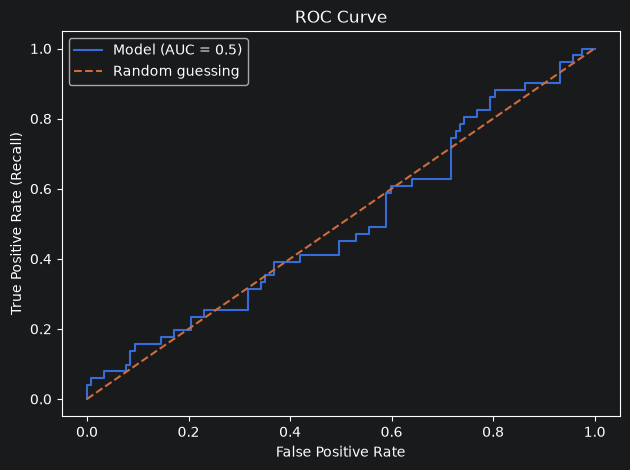


TEST 3: Cross-validation (5 rounds)
  Accuracy in each round: [0.4  0.51 0.54 0.52 0.5 ]
  Average accuracy      : 0.495
  Recall in each round  : [0.37 0.54 0.54 0.48 0.5 ]
  Average recall        : 0.483

TEST 4: Prediction for a new person
  Chance of diabetes: 47.8 %
  Prediction: No diabetes

DONE. Results saved in the results folder:
  test_scores.csv, test_confusion_matrix.png, roc_curve.png, cross_validation.csv


In [4]:
"""
test_model.py  -  Step 5 of the Diabetes Prediction project: MODEL TESTING

What this script does:
    1. Loads the saved model, the scaler and the data
    2. Test 1: scores the model on the hidden test data
    3. Test 2: measures ROC-AUC and draws the ROC curve
    4. Test 3: runs 5-fold cross-validation to check the result is stable
    5. Test 4: predicts the risk for one brand-new person
    6. Saves every result to the results/ folder

Input files : best_model.pkl, scaler.pkl, X_train.csv, y_train.csv, X_test.csv, y_test.csv
Output files: results/ folder (scores, ROC curve, confusion matrix, cross-validation)
"""

import os
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)

os.makedirs("results", exist_ok=True)


# =====================================================================
# STEP 1: LOAD THE SAVED MODEL, SCALER AND DATA
# =====================================================================
# The model and scaler were saved earlier, so we do not train again.
# The scaler is needed to prepare new people's values in the same way
# as the training data.
print("STEP 1: Loading model, scaler and data")

model = joblib.load("best_model.pkl")
scaler = joblib.load("scaler.pkl")
X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv").squeeze()

print("  Model type:", type(model).__name__)
print("  Test rows :", len(X_test))


# =====================================================================
# TEST 1: SCORE ON THE HIDDEN TEST DATA
# =====================================================================
# The model has never seen these rows, so this shows how well it works
# on new data.
#   Accuracy  : share of all predictions that were correct
#   Precision : when the model says "diabetes", how often it is right
#   Recall    : of all real diabetes cases, how many the model found
#   F1        : one number that balances precision and recall
print("\nTEST 1: Score on the hidden test data")

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions, zero_division=0)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

print("  Accuracy :", round(accuracy, 3))
print("  Precision:", round(precision, 3))
print("  Recall   :", round(recall, 3))
print("  F1 score :", round(f1, 3))

report = classification_report(y_test, predictions, target_names=["No Diabetes", "Diabetes"])
print(report)

# The confusion matrix shows the four possible outcomes:
#   top-left     = correctly said "no diabetes"
#   top-right    = false alarm (said diabetes, but the person is healthy)
#   bottom-left  = MISSED CASE (said healthy, but the person has diabetes)
#   bottom-right = correctly said "diabetes"
matrix = confusion_matrix(y_test, predictions)
print("  Confusion matrix:\n", matrix)



pd.DataFrame({"Metric": ["Accuracy", "Precision", "Recall", "F1"],
              "Score": [accuracy, precision, recall, f1]}).round(3).to_csv(
    "results/test_scores.csv", index=False)


# =====================================================================
# TEST 2: ROC-AUC
# =====================================================================
# Instead of a yes/no answer, the model gives a probability. ROC-AUC
# measures how well those probabilities separate the two groups:
#   0.5 = no better than guessing, 1.0 = perfect.
# The ROC curve should bend well above the dashed "guessing" line.
print("\nTEST 2: ROC-AUC")

probabilities = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, probabilities)
print("  ROC-AUC:", round(auc, 3))

fpr, tpr, _ = roc_curve(y_test, probabilities)
plt.plot(fpr, tpr, label="Model (AUC = " + str(round(auc, 2)) + ")")
plt.plot([0, 1], [0, 1], "--", label="Random guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("results/roc_curve.png", dpi=150)
plt.show()


# =====================================================================
# TEST 3: CROSS-VALIDATION
# =====================================================================
# One test split can be lucky or unlucky. Cross-validation splits the
# training data 5 different ways, tests each time, and shows all 5 scores.
# If the scores are similar, the result is stable and can be trusted.
print("\nTEST 3: Cross-validation (5 rounds)")

cv_accuracy = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
cv_recall = cross_val_score(model, X_train, y_train, cv=5, scoring="recall")

print("  Accuracy in each round:", cv_accuracy.round(2))
print("  Average accuracy      :", round(cv_accuracy.mean(), 3))
print("  Recall in each round  :", cv_recall.round(2))
print("  Average recall        :", round(cv_recall.mean(), 3))

pd.DataFrame({"Round": [1, 2, 3, 4, 5],
              "Accuracy": cv_accuracy, "Recall": cv_recall}).round(3).to_csv(
    "results/cross_validation.csv", index=False)


# =====================================================================
# TEST 4: PREDICT FOR A BRAND-NEW PERSON
# =====================================================================
# This checks the whole pipeline works end to end. The new values must be
# scaled with the saved scaler first, or the prediction would be wrong.
print("\nTEST 4: Prediction for a new person")

new_person = pd.DataFrame([{
    "Pregnancies": 2, "Glucose": 150, "BloodPressure": 80, "SkinThickness": 25,
    "Insulin": 120, "BMI": 32, "DiabetesPedigreeFunction": 0.6, "Age": 45,
}])
new_person_scaled = scaler.transform(new_person)
new_person_scaled = pd.DataFrame(new_person_scaled, columns=new_person.columns)

chance = model.predict_proba(new_person_scaled)[0][1]
print("  Chance of diabetes:", round(chance * 100, 1), "%")
print("  Prediction:", "Diabetes" if chance >= 0.5 else "No diabetes")


print("\nDONE. Results saved in the results folder:")
print("  test_scores.csv, test_confusion_matrix.png, roc_curve.png, cross_validation.csv")

In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, confusion_matrix

# ---------- 1. Load the data ----------
df = pd.read_csv("diabetes.csv")
print("Rows:", len(df))

# ---------- 2. Clean the data ----------
# In these columns, a 0 means "not measured". Replace it with the median value.
cols_with_fake_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in cols_with_fake_zeros:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

# ---------- 3. Separate inputs (X) and answer (y) ----------
X = df.drop(columns="Outcome")
y = df["Outcome"]

# ---------- 4. Split into training (80%) and test (20%) ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------- 5. Scale the numbers ----------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------- 6. Train two models ----------
log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train_scaled, y_train)

forest_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
forest_model.fit(X_train_scaled, y_train)

# ---------- 7. Test both models ----------
for name, model in [("Logistic Regression", log_model), ("Random Forest", forest_model)]:
    predictions = model.predict(X_test_scaled)
    chances = model.predict_proba(X_test_scaled)[:, 1]
    print("\n", name)
    print("Accuracy:", round(accuracy_score(y_test, predictions), 3))
    print("Recall  :", round(recall_score(y_test, predictions), 3))
    print("ROC-AUC :", round(roc_auc_score(y_test, chances), 3))
    print(confusion_matrix(y_test, predictions))

# ---------- 8. Save the model and scaler for the app ----------
joblib.dump(log_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("\nSaved best_model.pkl and scaler.pkl")

# ---------- 9. Try one new person ----------
new_person = pd.DataFrame([{
    "Pregnancies": 2, "Glucose": 150, "BloodPressure": 80, "SkinThickness": 25,
    "Insulin": 120, "BMI": 32, "DiabetesPedigreeFunction": 0.6, "Age": 45,
}])
chance = log_model.predict_proba(scaler.transform(new_person))[0][1]
print("Chance of diabetes:", round(chance * 100, 1), "%")

Rows: 768

 Logistic Regression
Accuracy: 0.734
Recall  : 0.704
ROC-AUC : 0.813
[[75 25]
 [16 38]]

 Random Forest
Accuracy: 0.74
Recall  : 0.685
ROC-AUC : 0.827
[[77 23]
 [17 37]]

Saved best_model.pkl and scaler.pkl
Chance of diabetes: 71.0 %


Glucose                     25.8
BMI                         16.7
Age                         12.6
DiabetesPedigreeFunction    11.9
Insulin                     10.1
BloodPressure                8.0
SkinThickness                7.6
Pregnancies                  7.4
dtype: float64


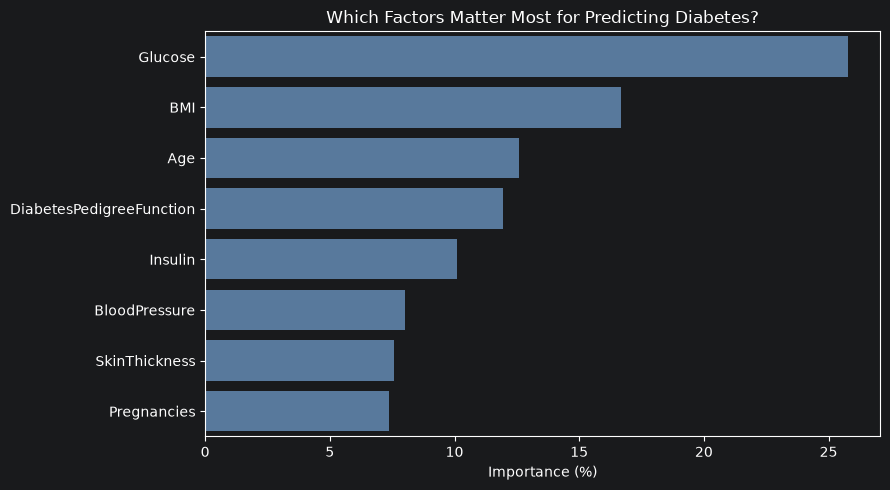

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# ---------- 1. Load and clean the data ----------
df = pd.read_csv("diabetes.csv")

cols_with_fake_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in cols_with_fake_zeros:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

# ---------- 2. Split the data ----------
X = df.drop(columns="Outcome")
y = df["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------- 3. Train the Random Forest ----------
forest = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
forest.fit(X_train, y_train)

# ---------- 4. Get the importance score of each column ----------
importance = pd.Series(forest.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)
print((importance * 100).round(1))

# ---------- 5. Draw the chart ----------
plt.figure(figsize=(9, 5))
sns.barplot(x=importance.values * 100, y=importance.index, color="#4C78A8")
plt.title("Which Factors Matter Most for Predicting Diabetes?")
plt.xlabel("Importance (%)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()
